# Salt-and-Pepper DAE: Optuna Bottleneck Search

This notebook adapts `dae_testing_no_skip_bottleneck32.ipynb`. It keeps the same plain convolutional autoencoder (no skip connections), Oxford-IIIT Pet split, 128×128 inputs, and salt-and-pepper corruption. Optuna tunes the bottleneck channel count (`bottleneck_ch`), which controls the width of the compressed representation at 16×16.

Trials are ranked by their best validation BCE loss. The test split is reserved for a single evaluation after the winning configuration is retrained.

**Search space:** bottleneck channels `{8, 16, 32, 64}` and learning rate `[1e-4, 3e-3]` (log scale).

In [10]:
# Install only if needed in this environment:
# %pip install optuna torchmetrics scipy

import gc
import json
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import optuna
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchmetrics.image import StructuralSimilarityIndexMeasure
from optuna.trial import TrialState

# ---------------- configuration ----------------
IMG_SIZE = 128
BATCH_SIZE = 32
TRIALS = 20
TRIAL_EPOCHS = 8       # short schedule for comparing trials
FINAL_EPOCHS = 60      # retraining schedule for the selected configuration
TRAIN_NOISE = 0.10
SEED = 42
NUM_WORKERS = 2
STUDY_NAME = "dae_saltpepper_bottleneck"
STORAGE = "sqlite:///dae_saltpepper_bottleneck.db"
# -----------------------------------------------

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)


Device: cuda


## Load the official local data split

The notebook locates the repository from either the repository root or `research/notebooks`. It reads the official split manifest and image files already stored under `research/datasets`; it does not download data.

In [2]:
here = Path.cwd().resolve()
repo_candidates = [here, *here.parents]
REPO_ROOT = next(
    (p for p in repo_candidates if (p / "research/datasets/oxford-iiit-pet/images").is_dir()),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError("Could not locate research/datasets/oxford-iiit-pet/images")

PET_IMAGES_DIR = REPO_ROOT / "research/datasets/oxford-iiit-pet/images"
SPLIT_MANIFEST = REPO_ROOT / "research/split_manifest_official.json"
with SPLIT_MANIFEST.open() as f:
    split_manifest = json.load(f)

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

class LocalPetImages(Dataset):
    def __init__(self, filenames, transform):
        self.paths = [PET_IMAGES_DIR / name for name in filenames]
        missing = [p for p in self.paths if not p.is_file()]
        if missing:
            raise FileNotFoundError(f"Missing image: {missing[0]}")
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        with Image.open(self.paths[index]) as image:
            return self.transform(image.convert("RGB")), 0

train_ds = LocalPetImages(split_manifest["train"], transform)
val_ds = LocalPetImages(split_manifest["val"], transform)
test_ds = LocalPetImages(split_manifest["test"], transform)
print(f"Images: train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}")


Images: train=2944, val=736, test=3669


## Corruption and model

The architecture matches the attached no-skip notebook. Only the number of channels in the two bottleneck convolutions is parameterized. Because the encoder downsamples three times, the representation has shape `(batch, bottleneck_ch, 16, 16)` for 128×128 inputs.

In [3]:
def add_salt_pepper(x, amount=0.10, salt_vs_pepper=0.5, generator=None):
    # One corruption decision per pixel, shared across RGB channels.
    batch, channels, height, width = x.shape
    r = torch.rand(batch, 1, height, width, device=x.device, generator=generator)
    pepper = r < amount * (1 - salt_vs_pepper)
    salt = (r >= amount * (1 - salt_vs_pepper)) & (r < amount)
    noisy = x.masked_fill(pepper.expand_as(x), 0.0)
    return noisy.masked_fill(salt.expand_as(x), 1.0)

class DenoisingAE(nn.Module):
    def __init__(self, ch=64, bottleneck_ch=32):
        super().__init__()
        self.enc1 = nn.Sequential(nn.Conv2d(3, ch, 3, padding=1), nn.ReLU(inplace=True))
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = nn.Sequential(nn.Conv2d(ch, ch, 3, padding=1), nn.ReLU(inplace=True))
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = nn.Sequential(nn.Conv2d(ch, ch, 3, padding=1), nn.ReLU(inplace=True))
        self.pool3 = nn.MaxPool2d(2)
        self.bottleneck = nn.Sequential(
            nn.Conv2d(ch, bottleneck_ch, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(bottleneck_ch, bottleneck_ch, 3, padding=1), nn.ReLU(inplace=True),
        )
        self.dec3 = nn.Sequential(nn.Conv2d(bottleneck_ch, ch, 3, padding=1), nn.ReLU(inplace=True))
        self.dec2 = nn.Sequential(nn.Conv2d(ch, ch, 3, padding=1), nn.ReLU(inplace=True))
        self.dec1 = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(ch, 3, 3, padding=1), nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.enc1(x)
        x = self.enc2(self.pool1(x))
        x = self.enc3(self.pool2(x))
        z = self.bottleneck(self.pool3(x))
        x = self.dec3(F.interpolate(z, scale_factor=2, mode="nearest"))
        x = self.dec2(F.interpolate(x, scale_factor=2, mode="nearest"))
        return self.dec1(F.interpolate(x, scale_factor=2, mode="nearest"))

# Confirm the output size and bottleneck shape for the initial 32-channel setting.
probe = DenoisingAE(ch=64, bottleneck_ch=32).to(device).eval()
with torch.inference_mode():
    dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE, device=device)
    features = probe.enc3(probe.pool2(probe.enc2(probe.pool1(probe.enc1(dummy)))))
    z = probe.bottleneck(probe.pool3(features))
    print("Bottleneck:", tuple(z.shape), "Output:", tuple(probe(dummy).shape))
del probe


Bottleneck: (1, 32, 16, 16) Output: (1, 3, 128, 128)


## Training and validation functions

Training corruption is regenerated for each batch. Validation uses the same seeded corruption stream at each epoch, so trial scores are comparable.

In [4]:
criterion = nn.BCELoss()

def make_loaders(batch_size):
    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS,
        pin_memory=(device.type == "cuda"),
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS,
        pin_memory=(device.type == "cuda"),
    )
    return train_loader, val_loader

def run_epoch(model, loader, optimizer=None, seed=None):
    training = optimizer is not None
    model.train(training)
    generator = None
    if seed is not None:
        generator = torch.Generator(device=device)
        generator.manual_seed(seed)
    total_loss, count = 0.0, 0
    with torch.set_grad_enabled(training):
        for clean, _ in loader:
            clean = clean.to(device, non_blocking=True)
            noisy = add_salt_pepper(clean, TRAIN_NOISE, generator=generator)
            prediction = model(noisy)
            loss = criterion(prediction, clean)
            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * clean.size(0)
            count += clean.size(0)
    return total_loss / count


## Optuna objective

Optuna searches bottleneck widths `{8, 16, 32, 64}` and learning rate. Each trial returns its lowest validation BCE over the short trial schedule. Median pruning can stop trials that are clearly behind.

In [5]:
def objective(trial):
    bottleneck_ch = trial.suggest_categorical("bottleneck_ch", [8, 16, 32, 64])
    lr = trial.suggest_float("lr", 1e-4, 3e-3, log=True)
    set_seed(SEED + trial.number)
    train_loader, val_loader = make_loaders(BATCH_SIZE)
    model = DenoisingAE(ch=64, bottleneck_ch=bottleneck_ch).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    best_val = float("inf")
    try:
        for epoch in range(1, TRIAL_EPOCHS + 1):
            train_loss = run_epoch(model, train_loader, optimizer=optimizer)
            val_loss = run_epoch(model, val_loader, seed=SEED)
            best_val = min(best_val, val_loss)
            trial.report(val_loss, step=epoch)
            print(f"Trial {trial.number:03d} | epoch {epoch:02d}/{TRIAL_EPOCHS} | "
                  f"bottleneck={bottleneck_ch:2d} | train={train_loss:.4f} | val={val_loss:.4f}")
            if trial.should_prune():
                raise optuna.TrialPruned()
        return best_val
    finally:
        del model, optimizer, train_loader, val_loader
        if device.type == "cuda":
            torch.cuda.empty_cache()
        gc.collect()

pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=2)
study = optuna.create_study(
    study_name=STUDY_NAME,
    storage=STORAGE,
    load_if_exists=True,
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=pruner,
)
study.optimize(objective, n_trials=TRIALS)

complete = study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])
pruned = study.get_trials(deepcopy=False, states=[TrialState.PRUNED])
print(f"Complete trials: {len(complete)} | Pruned trials: {len(pruned)}")
print("Best validation loss:", study.best_value)
print("Best parameters:", study.best_params)


[I 2026-10-03 23:24:21,997] A new study created in RDB with name: dae_saltpepper_bottleneck


Trial 000 | epoch 01/8 | bottleneck=16 | train=0.6271 | val=0.5772
Trial 000 | epoch 02/8 | bottleneck=16 | train=0.5726 | val=0.5644
Trial 000 | epoch 03/8 | bottleneck=16 | train=0.5661 | val=0.5620
Trial 000 | epoch 04/8 | bottleneck=16 | train=0.5635 | val=0.5604
Trial 000 | epoch 05/8 | bottleneck=16 | train=0.5619 | val=0.5574
Trial 000 | epoch 06/8 | bottleneck=16 | train=0.5597 | val=0.5560
Trial 000 | epoch 07/8 | bottleneck=16 | train=0.5584 | val=0.5550
Trial 000 | epoch 08/8 | bottleneck=16 | train=0.5571 | val=0.5544


[I 2026-10-03 23:25:15,062] Trial 0 finished with value: 0.5544319619303164 and parameters: {'bottleneck_ch': 16, 'lr': 0.0001700037298921101}. Best is trial 0 with value: 0.5544319619303164.


Trial 001 | epoch 01/8 | bottleneck=32 | train=0.6040 | val=0.5678
Trial 001 | epoch 02/8 | bottleneck=32 | train=0.5643 | val=0.5568
Trial 001 | epoch 03/8 | bottleneck=32 | train=0.5580 | val=0.5524
Trial 001 | epoch 04/8 | bottleneck=32 | train=0.5520 | val=0.5471
Trial 001 | epoch 05/8 | bottleneck=32 | train=0.5485 | val=0.5451
Trial 001 | epoch 06/8 | bottleneck=32 | train=0.5470 | val=0.5436
Trial 001 | epoch 07/8 | bottleneck=32 | train=0.5463 | val=0.5430
Trial 001 | epoch 08/8 | bottleneck=32 | train=0.5449 | val=0.5424


[I 2026-10-03 23:26:06,875] Trial 1 finished with value: 0.5423713767010233 and parameters: {'bottleneck_ch': 32, 'lr': 0.0011114989443094978}. Best is trial 1 with value: 0.5423713767010233.


...

Trial 018 | epoch 01/8 | bottleneck=64 | train=0.5969 | val=0.5616
Trial 018 | epoch 02/8 | bottleneck=64 | train=0.5636 | val=0.5559
Trial 018 | epoch 03/8 | bottleneck=64 | train=0.5561 | val=0.5514
Trial 018 | epoch 04/8 | bottleneck=64 | train=0.5491 | val=0.5457
Trial 018 | epoch 05/8 | bottleneck=64 | train=0.5468 | val=0.5430
Trial 018 | epoch 06/8 | bottleneck=64 | train=0.5463 | val=0.5424
Trial 018 | epoch 07/8 | bottleneck=64 | train=0.5449 | val=0.5425
Trial 018 | epoch 08/8 | bottleneck=64 | train=0.5443 | val=0.5413


[I 2026-10-03 23:34:53,204] Trial 18 finished with value: 0.5412672550781913 and parameters: {'bottleneck_ch': 64, 'lr': 0.0007108091151037429}. Best is trial 12 with value: 0.541155237218608.


Trial 019 | epoch 01/8 | bottleneck=32 | train=0.6088 | val=0.5654
Trial 019 | epoch 02/8 | bottleneck=32 | train=0.5640 | val=0.5573


[I 2026-10-03 23:35:06,499] Trial 19 pruned. 


Complete trials: 9 | Pruned trials: 11
Best validation loss: 0.541155237218608
Best parameters: {'bottleneck_ch': 32, 'lr': 0.0010048771522141395}


## Compare trials

This plot summarizes each completed trial by its best validation loss and bottleneck width.

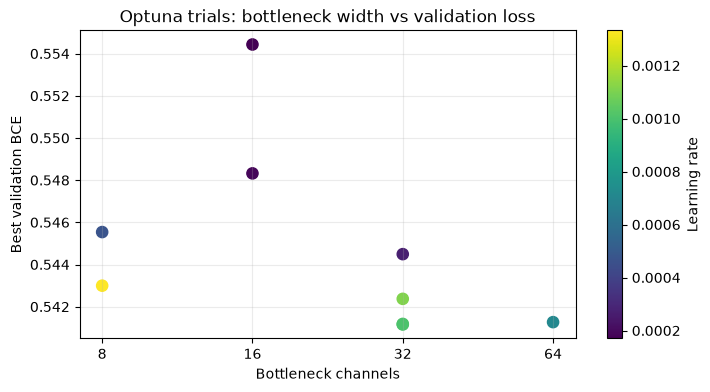

In [6]:
completed = [t for t in study.trials if t.state == TrialState.COMPLETE]
plt.figure(figsize=(8, 4))
plt.scatter(
    [t.params["bottleneck_ch"] for t in completed],
    [t.value for t in completed],
    c=[t.params["lr"] for t in completed], cmap="viridis", s=65,
)
plt.xscale("log", base=2)
plt.xticks([8, 16, 32, 64], ["8", "16", "32", "64"])
plt.xlabel("Bottleneck channels")
plt.ylabel("Best validation BCE")
plt.title("Optuna trials: bottleneck width vs validation loss")
plt.colorbar(label="Learning rate")
plt.grid(alpha=0.25)
plt.show()


## Retrain the winning configuration

Retrain from scratch with the selected bottleneck width and learning rate, choosing the best validation checkpoint. The output is saved separately from the source notebook's checkpoints.

Epoch 01/30 | train=0.5966 | val=0.5603 | 6.5s
Epoch 02/30 | train=0.5606 | val=0.5541 | 6.5s
Epoch 03/30 | train=0.5534 | val=0.5472 | 6.5s
Epoch 04/30 | train=0.5488 | val=0.5445 | 6.4s
Epoch 05/30 | train=0.5477 | val=0.5431 | 6.5s
Epoch 06/30 | train=0.5462 | val=0.5424 | 6.4s
Epoch 07/30 | train=0.5452 | val=0.5416 | 6.4s
Epoch 08/30 | train=0.5448 | val=0.5411 | 6.5s
Epoch 09/30 | train=0.5445 | val=0.5411 | 6.6s
Epoch 10/30 | train=0.5436 | val=0.5446 | 6.5s
Epoch 11/30 | train=0.5444 | val=0.5410 | 6.5s
Epoch 12/30 | train=0.5430 | val=0.5396 | 6.5s
Epoch 13/30 | train=0.5420 | val=0.5391 | 6.4s
Epoch 14/30 | train=0.5411 | val=0.5377 | 6.4s
Epoch 15/30 | train=0.5430 | val=0.5377 | 6.5s
Epoch 16/30 | train=0.5405 | val=0.5377 | 6.4s
Epoch 17/30 | train=0.5401 | val=0.5369 | 6.4s
Epoch 18/30 | train=0.5399 | val=0.5374 | 6.4s
Epoch 19/30 | train=0.5399 | val=0.5364 | 6.4s
Epoch 20/30 | train=0.5395 | val=0.5364 | 6.4s
Epoch 21/30 | train=0.5399 | val=0.5368 | 6.4s
Epoch 22/30 |

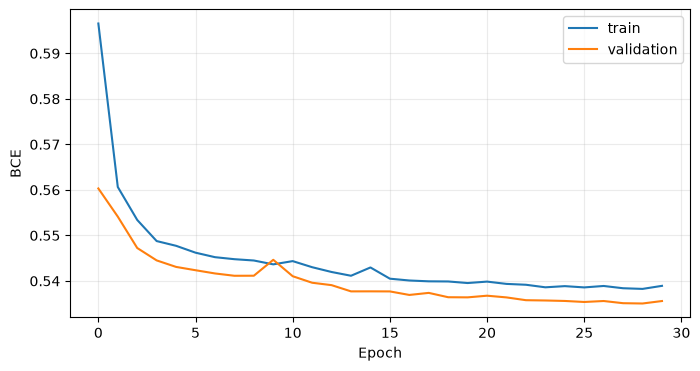

In [7]:
best_params = study.best_params
set_seed(SEED)
train_loader, val_loader = make_loaders(BATCH_SIZE)
model = DenoisingAE(ch=64, bottleneck_ch=best_params["bottleneck_ch"]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=best_params["lr"])
history = {"train": [], "val": []}
best_val = float("inf")
best_state = None

for epoch in range(1, FINAL_EPOCHS + 1):
    started = time.time()
    train_loss = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss = run_epoch(model, val_loader, seed=SEED)
    history["train"].append(train_loss)
    history["val"].append(val_loss)
    if val_loss < best_val:
        best_val = val_loss
        best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
    print(f"Epoch {epoch:02d}/{FINAL_EPOCHS} | train={train_loss:.4f} | val={val_loss:.4f} | "
          f"{time.time() - started:.1f}s")

model.load_state_dict(best_state)
model.to(device).eval()
print(f"Selected bottleneck: {best_params['bottleneck_ch']} channels; best val BCE: {best_val:.4f}")
plt.figure(figsize=(8, 4))
plt.plot(history["train"], label="train")
plt.plot(history["val"], label="validation")
plt.xlabel("Epoch")
plt.ylabel("BCE")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## Final held-out test evaluation

Evaluate the chosen model once on the official test split. PSNR and SSIM are reported for noisy input and reconstructed output.

In [8]:
def psnr_per_image(a, b):
    mse = (a - b).square().flatten(1).mean(1).clamp_min(1e-10)
    return 10 * torch.log10(1.0 / mse)

@torch.inference_mode()
def evaluate_test(model, loader, amount=TRAIN_NOISE, seed=123):
    model.eval()
    generator = torch.Generator(device=device)
    generator.manual_seed(seed)
    ssim_noisy = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
    ssim_denoised = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
    noisy_psnr, denoised_psnr = [], []
    for clean, _ in loader:
        clean = clean.to(device)
        noisy = add_salt_pepper(clean, amount, generator=generator)
        denoised = model(noisy)
        noisy_psnr.append(psnr_per_image(noisy, clean))
        denoised_psnr.append(psnr_per_image(denoised, clean))
        ssim_noisy.update(noisy, clean)
        ssim_denoised.update(denoised, clean)
    return {
        "psnr_noisy": torch.cat(noisy_psnr).mean().item(),
        "psnr_denoised": torch.cat(denoised_psnr).mean().item(),
        "ssim_noisy": ssim_noisy.compute().item(),
        "ssim_denoised": ssim_denoised.compute().item(),
    }

test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)
test_metrics = evaluate_test(model, test_loader)
print(f"Bottleneck channels: {best_params['bottleneck_ch']}")
print(f"PSNR: {test_metrics['psnr_noisy']:.2f} -> {test_metrics['psnr_denoised']:.2f} dB")
print(f"SSIM: {test_metrics['ssim_noisy']:.4f} -> {test_metrics['ssim_denoised']:.4f}")


Bottleneck channels: 32
PSNR: 14.91 -> 24.82 dB
SSIM: 0.2647 -> 0.6884


In [9]:
# Save the selected model and trial metadata to the repository's research/checkpoints folder.
checkpoint_path = REPO_ROOT / "research/checkpoints/dae_optuna_bottleneck_best.pt"
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
torch.save({
    "state_dict": model.state_dict(),
    "img_size": IMG_SIZE,
    "train_noise": TRAIN_NOISE,
    "bottleneck_ch": best_params["bottleneck_ch"],
    "learning_rate": best_params["lr"],
    "best_val_bce": best_val,
    "test_metrics": test_metrics,
}, checkpoint_path)
print("Saved:", checkpoint_path)


Saved: /home/zaifi/genai-assignment-1/research/checkpoints/dae_optuna_bottleneck_best.pt
